In [3]:
!git clone https://github.com/handel123/INFO257.git
%cd INFO257/Clustering



Cloning into 'INFO257'...
remote: Enumerating objects: 393, done.
remote: Counting objects: 100% (230/230), done.
remote: Compressing objects: 100% (192/192), done.
remote: Total 393 (delta 80), reused 162 (delta 32), pack-reused 163 (from 1)
Receiving objects: 100% (393/393), 11.31 MiB | 20.98 MiB/s, done.
Resolving deltas: 100% (149/149), done.
/content/INFO257/Clustering


### Entrega grupo 19 Estudiantes Handel Venegas, Javier Reyes
Uso de IA generativa: mayormente para generar código, comprender dominio del problema, mejora de redacción y conexión de ideas del texto de análisis.


### Notebook 1:  Clustering con K-means
En este notebook vamos a implementar el algoritmo de clustering K-means en R. El objetivo es entender como funciona este algoritmo y  aprender a utilizarlo con un ejemplo simple. Se incluye además la estrategia para definir el número de grupos k. Al final se propone un ejercicio con nuevos datos, con el fin de aprender a utilizar el algoritmo.

Para ello vamos a utilizar un conjunto de datos provenientes de un estudio de granos pertenecientes a distintas variedades de trigo. Los atributos de los datos provienen de una visualización de alta calidad de la estructura interna del grano utilizando una técnica de rayos X suaves. La ventaja de esta técnica es que no es destructiva y es considerablemente más económica que otras técnicas de imagen más sofisticadas como la microscopía de barrido o la tecnología láser. Las imágenes se registraron en placas KODAK de rayos X de 13x18 cm. Los estudios se llevaron a cabo utilizando grano de trigo cosechado en combinación procedente de campos experimentales, explorados en el Instituto de Agrofísica de la Academia de Ciencias de Polonia en Lublin.


Los atributos observados son seis parámetros geométricos medidos en los granos de trigo:

V1: área A

V2: perímetro P

V3: longitud de la semilla

V4: ancho de la semilla

V5: coeficiente de asimetría

V6: longitud de la ranura de la semilla

Se trata de analizar de que manera estos atributos permiten generar grupos en los datos que correspondan idealmente a cada variedad de trigo disponible en los datos.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


datos = pd.read_csv("../data/semillas1.txt", sep='\s+')
datos.head()


<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2213/3712338571.py:7: SyntaxWarning: invalid escape sequence '\s'
  datos = pd.read_csv("../data/semillas1.txt", sep='\s+')


,V1,V2,V3,V4,V5,V6
1,16.63,15.46,6.053,3.465,2.040,5.877
2,20.03,16.90,6.493,3.857,3.063,6.320
3,15.60,15.11,5.832,3.286,2.725,5.752
4,10.82,12.83,5.180,2.630,4.853,5.089
5,14.79,14.52,5.545,3.291,2.704,5.111


In [ ]:
datos.corr()

,V1,V2,V3,V4,V5,V6
V1,1.000000,0.994341,0.949985,0.970771,-0.229572,0.863693
V2,0.994341,1.000000,0.972422,0.944829,-0.217340,0.890784
V3,0.949985,0.972422,1.000000,0.860415,-0.171562,0.932806
V4,0.970771,0.944829,0.860415,1.000000,-0.258036,0.749131
V5,-0.229572,-0.217340,-0.171562,-0.258036,1.000000,-0.011079
V6,0.863693,0.890784,0.932806,0.749131,-0.011079,1.000000


      V1    V2    V3    V4    V5    V6
1  16.63 15.46 6.053 3.465 2.040 5.877
2  20.03 16.90 6.493 3.857 3.063 6.320
3  15.60 15.11 5.832 3.286 2.725 5.752
4  10.82 12.83 5.180 2.630 4.853 5.089
5  14.79 14.52 5.545 3.291 2.704 5.111
6  14.03 14.16 5.438 3.201 1.717 5.001
7  16.44 15.25 5.884 3.505 1.969 5.533
8  13.78 14.06 5.479 3.156 3.136 4.872
9  18.76 16.20 6.172 3.796 3.120 6.053
10 12.88 13.50 5.139 3.119 2.352 4.607


       V1              V2              V3              V4       
 Min.   :10.59   Min.   :12.41   Min.   :4.899   Min.   :2.630  
 1st Qu.:12.27   1st Qu.:13.45   1st Qu.:5.262   1st Qu.:2.944  
 Median :14.36   Median :14.32   Median :5.524   Median :3.237  
 Mean   :14.85   Mean   :14.56   Mean   :5.629   Mean   :3.259  
 3rd Qu.:17.30   3rd Qu.:15.71   3rd Qu.:5.980   3rd Qu.:3.562  
 Max.   :21.18   Max.   :17.25   Max.   :6.675   Max.   :4.033  
       V5              V6       
 Min.   :0.765   Min.   :4.519  
 1st Qu.:2.562   1st Qu.:5.045  
 Median :3.599   Median :5.223  
 Mean   :3.700   Mean   :5.408  
 3rd Qu.:4.769   3rd Qu.:5.877  
 Max.   :8.456   Max.   :6.550  

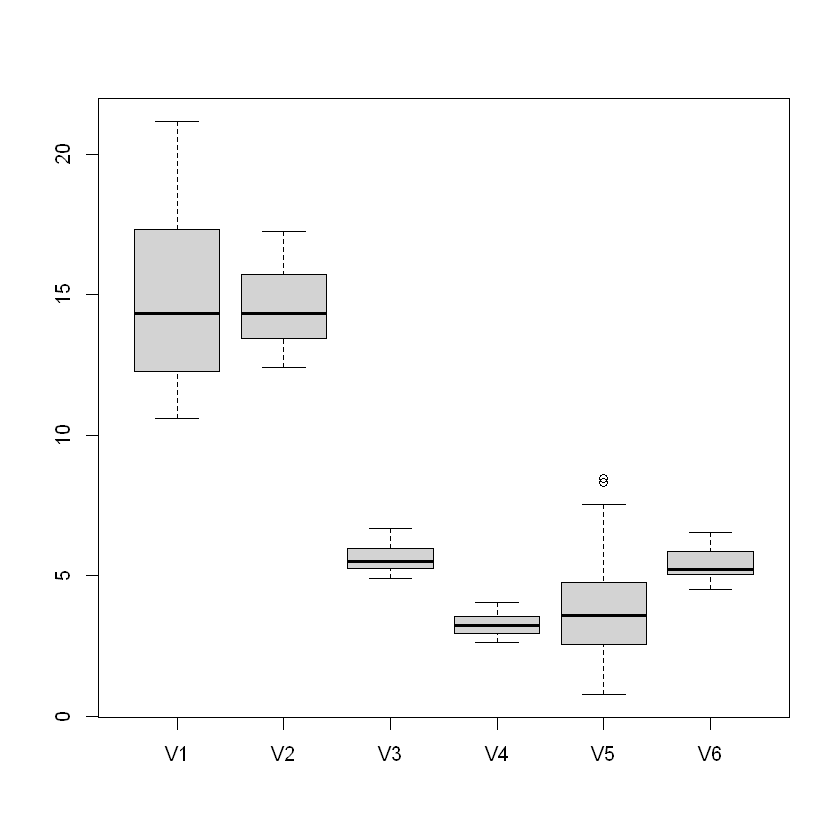

In [ ]:
library(cluster)
library(ggplot2)

#ruta datos
#lee datos del archivo de texto como una matriz. La primera #columna se utiliza como vector de nombres de las filas
datos <-read.table("..//data//semillas1.txt",dec=".")

print(datos[1:10,])
summary(datos)
boxplot(datos)

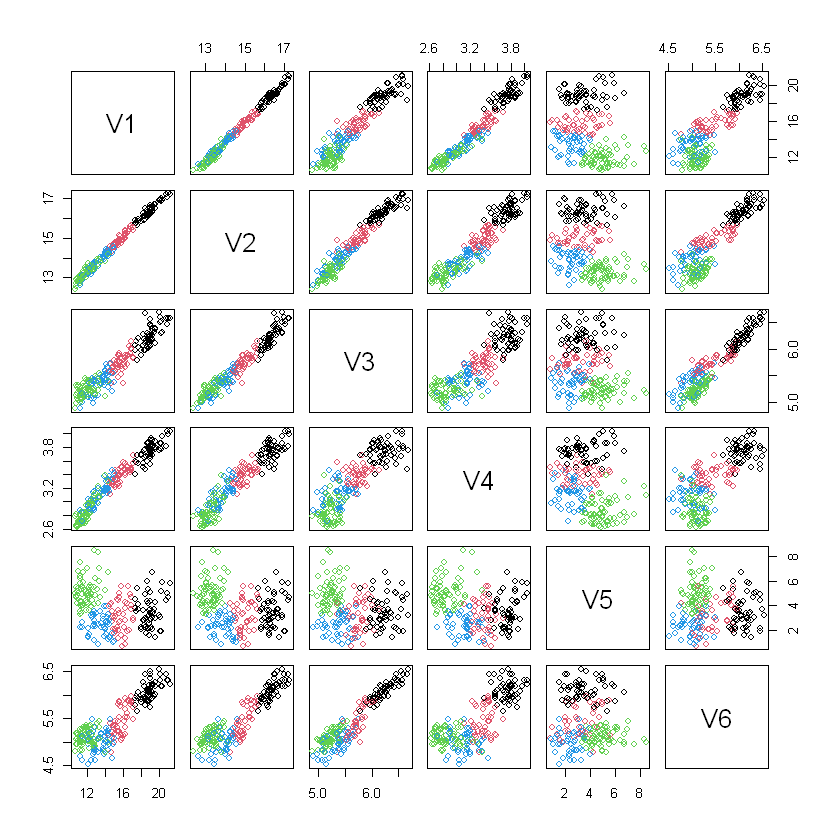

In [ ]:
#ingresar valor de k0
k0=4
cl<-kmeans(datos,k0,iter.max=1000,nstart=10)
#grafica los datos coloreados con el grupo asignado en planos de pares de variables
pairs(datos,col=cl$cluster)

\Al considerar 2,3 o 4 grupos con el algoritmo KMeans, se obtienen grupos bastante bien diferenciados por las variables area, perimetro longitud de las semillas. Las tres últimas variables tienen valores con mayor nivel de confusión entre los grupos definidos por kmeans.

Call:
princomp(x = datos, cor = TRUE)

Standard deviations:
    Comp.1     Comp.2     Comp.3     Comp.4     Comp.5     Comp.6 
2.16788117 1.00229308 0.49446476 0.20713724 0.08426551 0.03461094 

 6  variables and  210 observations.


,Comp.1,Comp.2,Comp.3,Comp.4,Comp.5,Comp.6
1,3.0936321,-0.2499533,-0.04446158,-0.04386905,0.0115749668,0.013458399
2,0.6362517,0.3177031,0.12251442,0.05021075,-0.0084876163,-0.025890456
3,-2.1376924,-0.7392228,-0.11677986,-0.03800567,-0.0009242843,0.005265824
4,-1.1731198,1.0501576,0.10256003,0.05800065,-0.0041432679,0.001410480


K-means clustering with 4 clusters of sizes 54, 44, 66, 46

Cluster means:
        V1       V2       V3       V4       V5       V6
1 18.96296 16.39667 6.242722 3.749926 3.540333 6.100778
2 15.71909 14.97659 5.745182 3.398500 3.187045 5.448386
3 11.91439 13.26152 5.231227 2.863939 5.068288 5.105348
4 13.39109 13.86522 5.366000 3.114283 2.415804 4.990674

Clustering vector:
  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18  19  20 
  2   1   2   3   2   4   2   4   1   4   3   2   2   2   1   3   3   2   2   3 
 21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36  37  38  39  40 
  3   1   2   3   3   2   3   4   4   1   2   4   3   2   1   1   1   3   2   3 
 41  42  43  44  45  46  47  48  49  50  51  52  53  54  55  56  57  58  59  60 
  4   3   1   4   3   1   1   3   3   3   1   4   2   3   2   4   2   2   1   3 
 61  62  63  64  65  66  67  68  69  70  71  72  73  74  75  76  77  78  79  80 
  4   1   4   2   1   4   1   2   1   3   1   4   2   1   

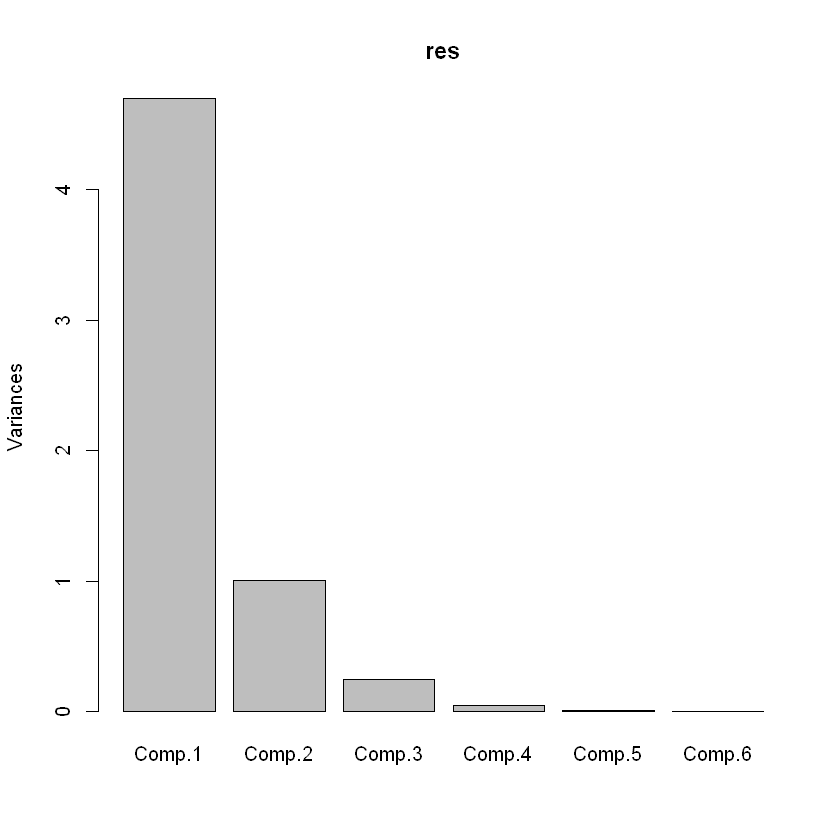

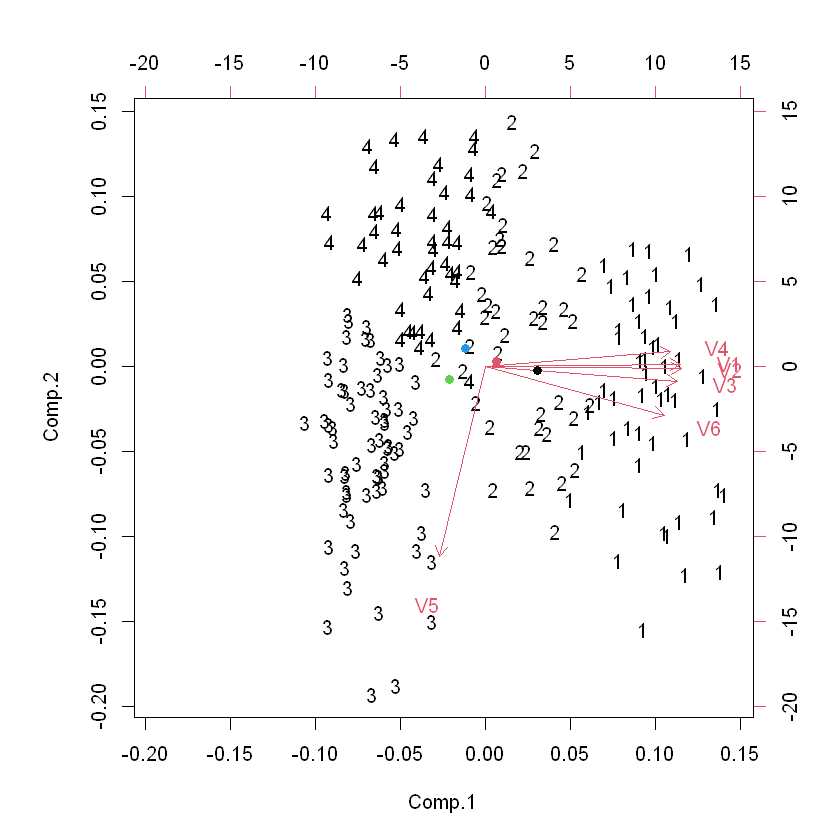

In [ ]:
#Análisis de Componentes Principales para graficar los grupos obtenidos
#Calcula plano de componentes principales y grafica las observaciones con el número de su grupo
res <- princomp(datos, cor=TRUE)
print(res)
plot(res)
res2 <- predict(res,cl$centers)
res2
cl
biplot(res,xlabs=cl$cluster)
#grafica los centros de cada grupo en el plano de componentes principales utilizando colores distintos
points(res2[,1:2],col=1:k0,pch=19)


La representación de los grupos en el primer plano principal nos permite distinguir que el grupo 2 representa a las semillas con mayores valores de todas las variables excepto V5, el coeficiente de simetría. El grupo 1 representa las semillas con valores intermendios de las distintas variables  y los grupos 3 y 4 con los menores valores. Se distinguen el grupo 3 del 4 por sus mayores valores de V5 el coeficiente de simetría.


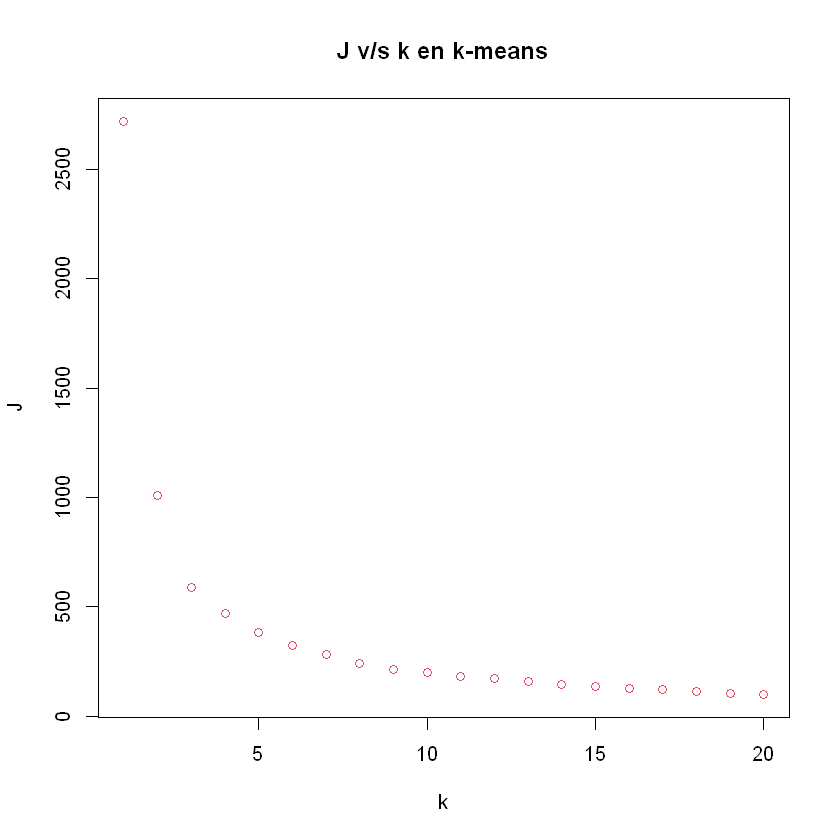

In [ ]:
#Estrategia para elegir K, el numero de grupos
#J suma cuadrado de las distancias por cada k utilizado
#K-means
J<-rep(0,20)
fin_iter<-20


for (k in 1:fin_iter){
     cl<-kmeans(datos,k,iter.max=1000,nstart=10)
	 J[k]<-cl$tot.withinss
}


plot(1:fin_iter,J,xlab="k",ylab="J",type="p",main="J v/s k en k-means",col=2)

### Ejercicio 1:

1. De acuerdo al gráfico obtenido, cuál es el valor de K mas apropiado? Explique su decisión.
k=2, porque agregar mas clusteres a partir de ese codo, mejora muy poco el modelo.
2. Realice nuevamente los cálculos con el K óptimo y  caracterice los grupos obtenidos. Interprete sus resultados

In [ ]:
df <- data.frame(datos)
k0=3
cl<-kmeans(datos,k0,iter.max=1000,nstart=10)
fviz_cluster(cl, df)

ERROR: Error in fviz_cluster(cl, df): no se pudo encontrar la función "fviz_cluster"


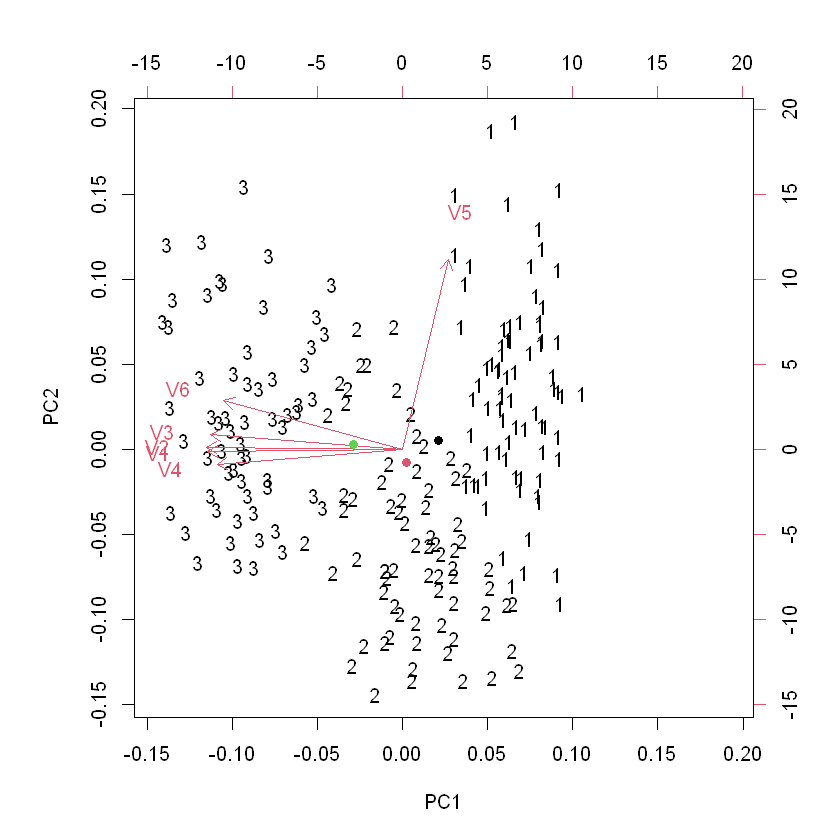

In [ ]:
res <- prcomp(datos,scale=TRUE)
res2 <- predict(res,cl$centers)
biplot(res,xlabs=cl$cluster)
points(res2[,1:2],col=1:k0,pch=19)

## Otras alternativas de cálculo

Welcome! Want to learn more? See two factoextra-related books at https://goo.gl/ve3WBa



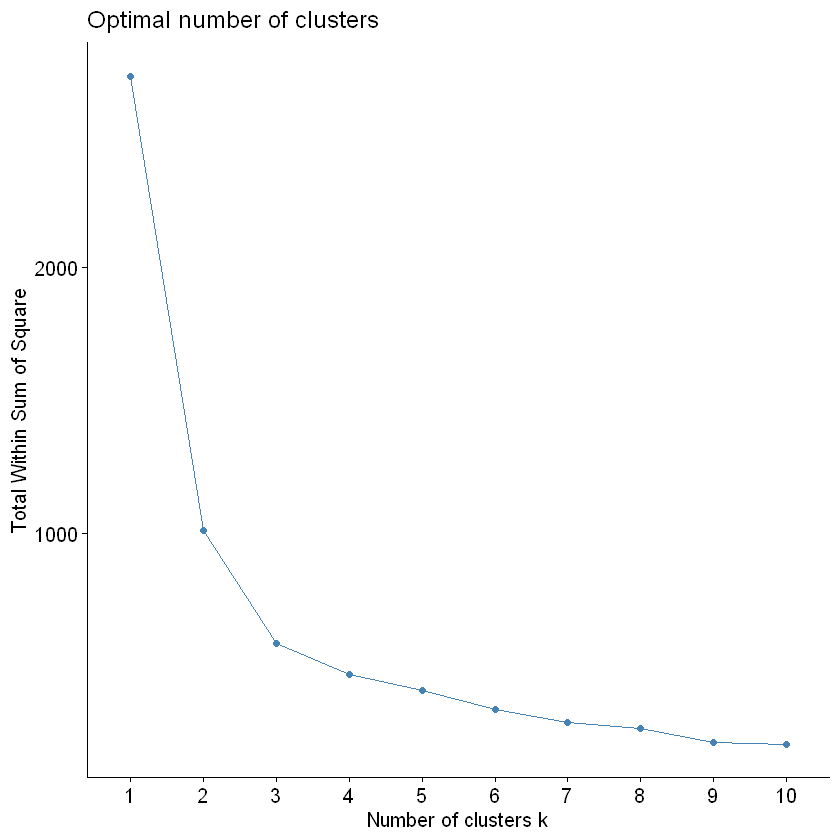

In [ ]:
library(cluster)
library(factoextra)
df <- data.frame(datos)
fviz_nbclust(df, kmeans, method = "wss")


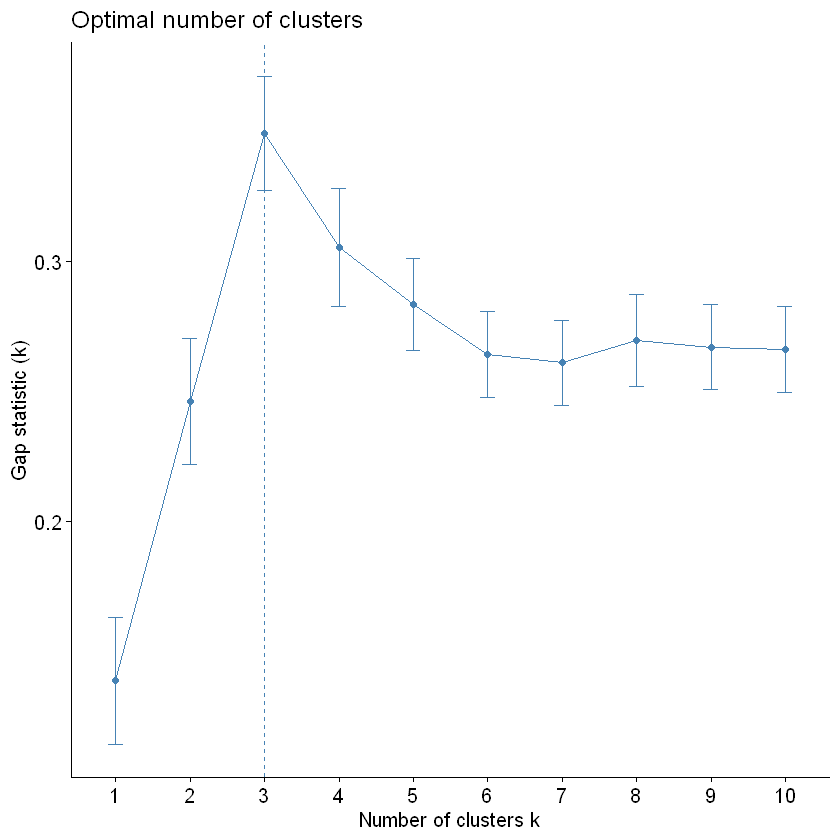

In [ ]:
#calculo de gap estadístico basado en el número de grupos:
#tasa entre la suma de distancias intragrupos con k grupos y con un sólo un grupo
gap_stat <- clusGap(df,
                    FUN = kmeans,
                    nstart = 25,
                    K.max = 10,
                    B = 50)


fviz_gap_stat(gap_stat)

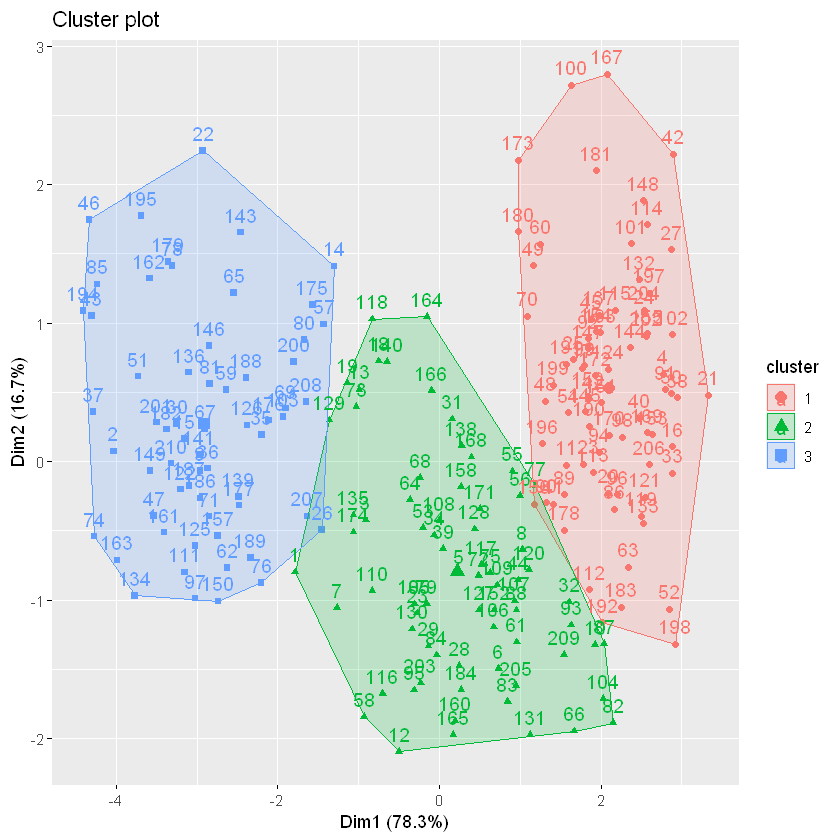

In [ ]:
fviz_cluster(cl, df)

### Ejercicio 2:
Realice un análisis de clustering con el conjunto de datos correspondiente a su grupo, para el cual ya realizó un análisis exploratorio y de PCA (No olvide de excluir la penúltima y última columna de sus datos originales).

1. Describa los datos y discuta la pertinencia de realizar un análisis de clustering o agrupamiento
2. Utilice k-means para realizar el clustering de los datos y calcule el K óptimo.
3. Caracterice los grupos obtenidos con el K óptimo. Interprete sus resultados


In [ ]:
!pwd

/content/INFO257/Clustering


In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import json

datos2 = pd.read_csv("../datasets_simulados/Grupo19.csv", sep=';')
datos2.head()


,imc,presion,actividad,colesterol,riesgo,riesgo_alto
0,28.10,160.39,4.28,246.05,15.04,True
1,27.26,140.95,3.65,220.10,14.95,True
2,29.84,122.89,3.04,296.52,15.83,False
3,24.75,124.92,4.34,230.52,15.95,True
4,28.66,143.67,3.78,269.12,17.49,True


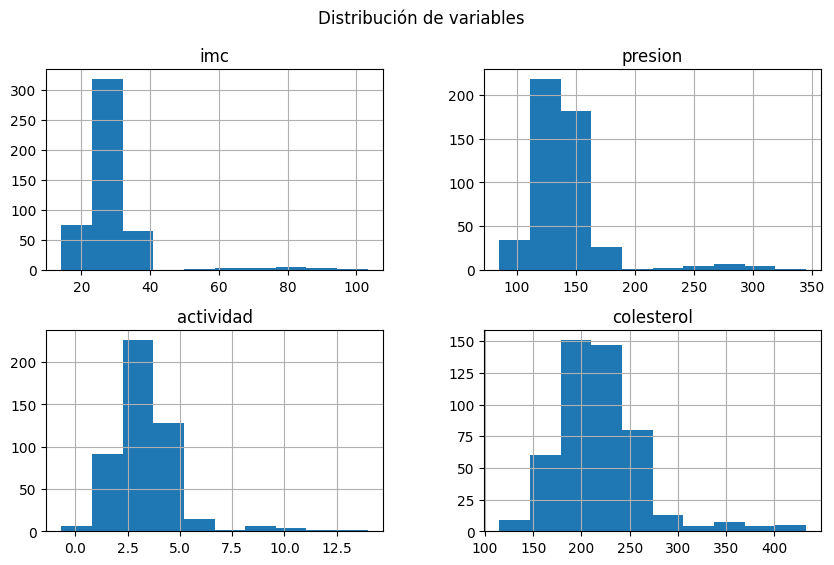

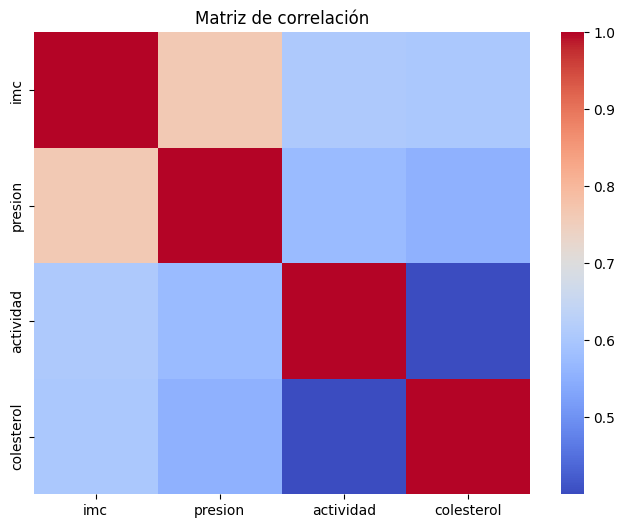

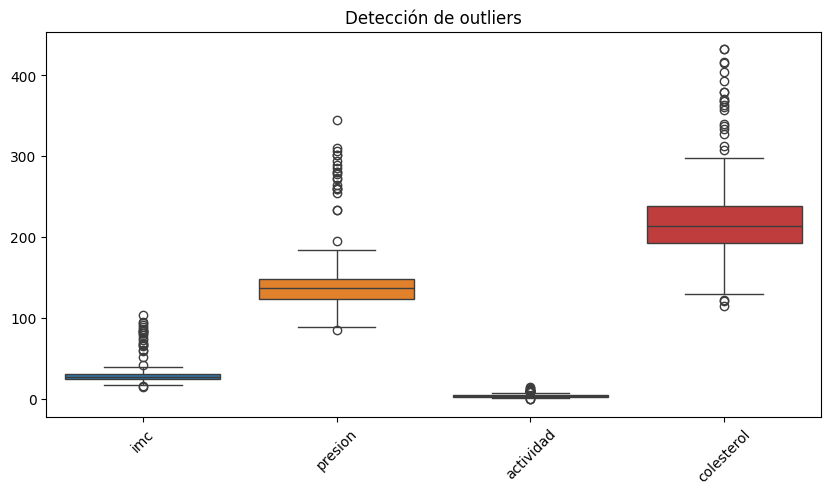

In [6]:


datos_eda = datos2.iloc[:, :-2].copy()


info = {
    "n_filas": int(datos_eda.shape[0]),
    "n_columnas": int(datos_eda.shape[1])
}


nulos = datos_eda.isnull().sum()

# Eliminar nulos
datos_eda = datos_eda.dropna()

descripcion = datos_eda.describe().to_dict()

datos_eda.hist(figsize=(10, 6))
plt.suptitle("Distribución de variables")
plt.show()
corr = datos_eda.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=False, cmap='coolwarm')
plt.title("Matriz de correlación")
plt.show()

# Variables altamente correlacionadas
corr_pairs = (
    corr.abs()
    .unstack()
    .sort_values(ascending=False)
)

corr_altas = [
    (str(i), str(j), float(v))
    for (i, j), v in corr_pairs.items()
    if i != j and v > 0.8
][:10]


outliers = {}

for col in datos_eda.columns:
    Q1 = datos_eda[col].quantile(0.25)
    Q3 = datos_eda[col].quantile(0.75)
    IQR = Q3 - Q1
    outlier_count = int(((datos_eda[col] < Q1 - 1.5 * IQR) |
                         (datos_eda[col] > Q3 + 1.5 * IQR)).sum())
    outliers[col] = outlier_count


plt.figure(figsize=(10, 5))
sns.boxplot(data=datos_eda)
plt.title("Detección de outliers")
plt.xticks(rotation=45)
plt.show()


stds = datos_eda.std().to_dict()


In [7]:
import numpy as np
import pandas as pd
import json


datos_limpios = datos2.iloc[:, :-2].copy()
reglas = {
    "IMC": (10, 60),              # rangos realistas
    "Presion": (50, 250),
    "Actividad": (0, None)        # no puede ser negativa
}

filas_invalidas = pd.Series(False, index=datos_limpios.index)

for col, (min_val, max_val) in reglas.items():
    if col in datos_limpios.columns:
        if min_val is not None:
            filas_invalidas |= datos_limpios[col] < min_val
        if max_val is not None:
            filas_invalidas |= datos_limpios[col] > max_val

n_eliminadas_reglas = int(filas_invalidas.sum())

# eliminar filas físicamente imposibles
datos_limpios = datos_limpios[~filas_invalidas]


outliers_antes = {}
outliers_despues = {}

for col in datos_limpios.columns:
    Q1 = datos_limpios[col].quantile(0.25)
    Q3 = datos_limpios[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # contar antes
    outliers_antes[col] = int(((datos_limpios[col] < lower) | (datos_limpios[col] > upper)).sum())

    datos_limpios[col] = np.clip(datos_limpios[col], lower, upper)

    # contar después
    outliers_despues[col] = int(((datos_limpios[col] < lower) | (datos_limpios[col] > upper)).sum())


se limpian datos fisicamente imposibles, y se sacan las columnas riesgo, al probablemente ser un dato derivado, y a riesgo_alto, por ser una etiqueta. Esto para no contaminar el clustering.

In [8]:

# eliminar filas con valores nulos
datos_cluster = datos_limpios.dropna()


In [9]:
datos_limpios.head()

,imc,presion,actividad,colesterol
0,28.10,160.39,4.28,246.05
1,27.26,140.95,3.65,220.10
2,29.84,122.89,3.04,296.52
3,24.75,124.92,4.34,230.52
4,28.66,143.67,3.78,269.12


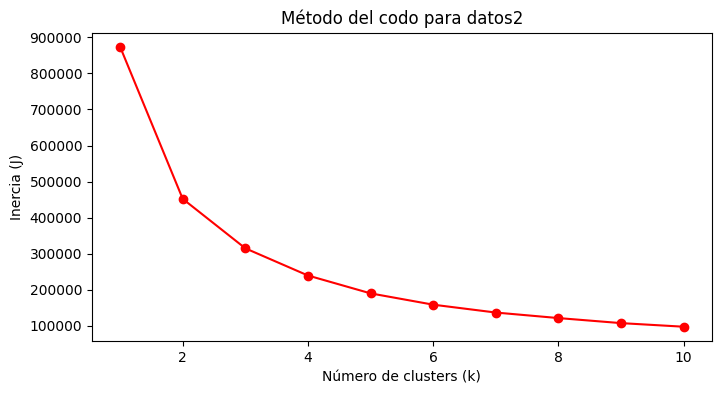

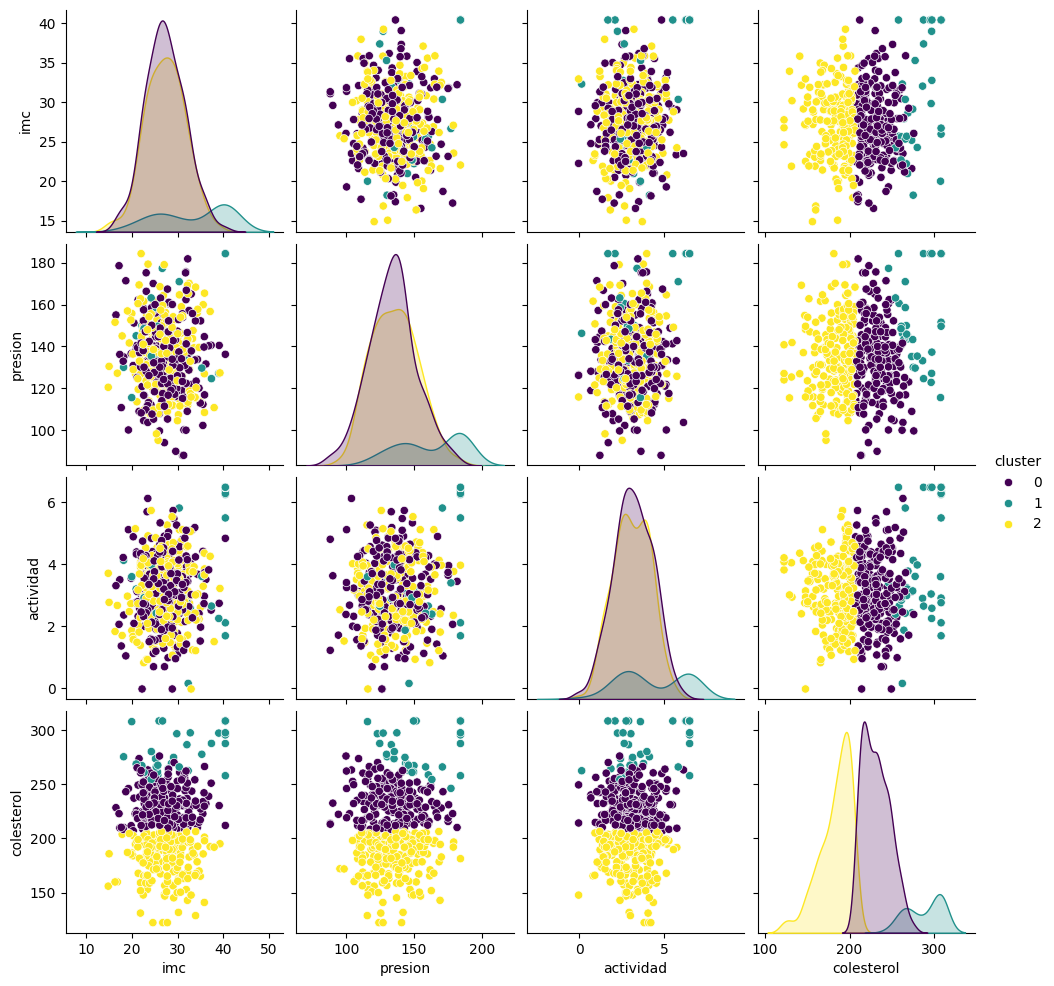

In [11]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Encontrar K optimo
inercia = []
rango_k = range(1, 11)
for k in rango_k:
    kmeans_test = KMeans(n_clusters=k, max_iter=1000, n_init=10, random_state=42)
    kmeans_test.fit(datos_cluster)
    inercia.append(kmeans_test.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(rango_k, inercia, marker='o', color='red')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia (J)')
plt.title('Método del codo para datos2')
plt.show()

# Calcular kmeans con el K óptimo

k_optimo = 3
kmeans_opt = KMeans(n_clusters=k_optimo, max_iter=1000, n_init=10, random_state=42)
clusters_opt = kmeans_opt.fit_predict(datos_cluster)

# matriz de pares
datos_grafico2 = datos_cluster.copy()
datos_grafico2['cluster'] = clusters_opt

sns.pairplot(datos_grafico2, hue='cluster', palette='viridis', diag_kind='kde')
plt.show()

Al considerar 3 grupos con el algoritmo KMeans, a pesar de que la regla del codo sugería 2, se obtienen grupos fuertemente desbalanceados. La conformación de estos nos permite distinguir que el grupo 2 representa una pequeña minoría de casos con los mayores valores en todas las variables analizadas, separándose notablemente del resto. Por su parte, los grupos 1 y 3 representan a la gran mayoría de las observaciones con valores marcadamente menores.

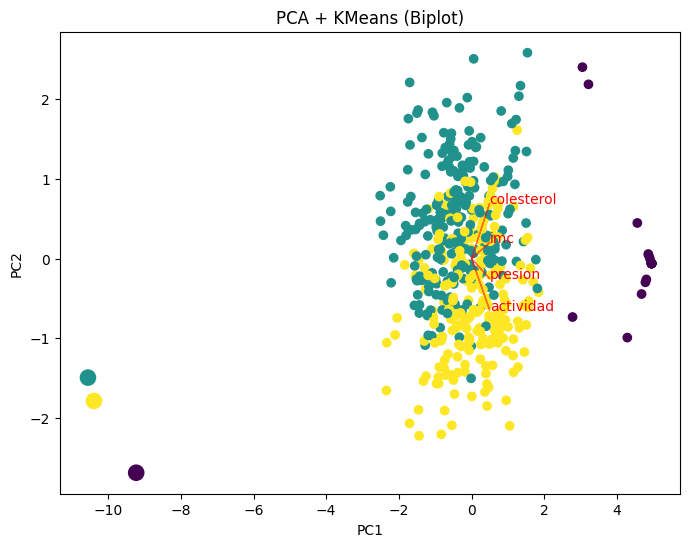

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import pandas as pd
import matplotlib.pyplot as plt

scaler = StandardScaler()
datos_std = scaler.fit_transform(datos_cluster)


pca = PCA()
pca.fit(datos_std)

scores = pca.transform(datos_std)


k0 = 3
kmeans = KMeans(n_clusters=k0, random_state=42, n_init=10)
clusters = kmeans.fit_predict(datos_std)


centros_df = pd.DataFrame(kmeans.cluster_centers_, columns=datos_cluster.columns)
centros_pca = pca.transform(scaler.transform(centros_df))

loadings = pca.components_.T[:, :2]


plt.figure(figsize=(8,6))

plt.scatter(scores[:,0], scores[:,1], c=clusters, cmap='viridis')

for i, var in enumerate(datos_cluster.columns):
    x, y = loadings[i]
    plt.arrow(0, 0, x, y, color='red', alpha=0.5)
    plt.text(x, y, var, color='red')

plt.scatter(centros_pca[:,0], centros_pca[:,1], c=range(k0), s=120, marker='o')

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA + KMeans (Biplot)")
plt.show()


Al usar 3 grupos con KMeans sobre el PCA, la separación no queda muy clara. Hay bastante mezcla en los datos: los grupos 1 y 2 prácticamente se pisan entre sí, están muy cerca y concentran la mayoría de los casos, con perfiles bastante parecidos.

El grupo 0 sí se alcanza a separar un poco más, pero representa solo a una parte más chica, con características algo distintas del resto.

Esto pasa porque el primer componente mezcla casi todas las variables (IMC, presión, actividad y colesterol), como si fuera un “nivel general” de los pacientes. El segundo componente intenta diferenciar más entre colesterol y actividad, pero no es lo suficiente como para separar bien a los grupos grandes.

Ahora validaremos si los clusters obtenidos (basados en variables biométricas y de estilo de vida) tienen alguna relación con el nivel de riesgo real de los pacientes.

In [14]:
datos_analisis_riesgo = datos2.loc[datos_cluster.index].copy()

datos_analisis_riesgo['cluster'] = clusters_opt

resumen_riesgo = datos_analisis_riesgo.groupby('cluster').agg(
    promedio_riesgo=('riesgo', 'mean'),
    proporcion_riesgo_alto=('riesgo_alto', 'mean'),
    cantidad_pacientes=('riesgo', 'count')
).reset_index()

resumen_riesgo['proporcion_riesgo_alto'] = (resumen_riesgo['proporcion_riesgo_alto'] * 100).round(2).astype(str) + '%'
resumen_riesgo['promedio_riesgo'] = resumen_riesgo['promedio_riesgo'].round(2)

display(resumen_riesgo)

,cluster,promedio_riesgo,proporcion_riesgo_alto,cantidad_pacientes
0,0,15.41,40.08810572687225%,226
1,1,26.40,46.666666666666664%,46
2,2,15.20,37.4384236453202%,204


Mirando cómo se relacionan los grupos con el nivel de riesgo, queda claro que el **Cluster 1** es el más preocupante. Aunque son poquitos pacientes (solo 46), tienen el promedio de riesgo más alto (26.40) y casi la mitad de ellos (46.6%) están en la categoría de 'riesgo alto'. Esto tiene todo el sentido con lo que vimos antes: este es el grupo de personas que tenía el IMC, la presión y el colesterol más altos.

Por el otro lado tenemos a los **Clusters 0 y 2**, que concentran a la gran mayoría de los pacientes. Estos dos grupos se parecen un montón entre sí y tienen un nivel de riesgo bastante más bajo (promedios cerca de 15 y entre un 37-40% de casos de riesgo alto). Esto confirma lo que ya habíamos notado en los gráficos anteriores: las personas de estos dos grupos tienen un perfil de salud muy parecido y presentan valores mucho mejores o controlados que los del Cluster 1.